
Logistic Regression Performance
Accuracy : 0.7532467532467533
Precision: 0.6666666666666666
Recall   : 0.6181818181818182
F1-score : 0.6415094339622641

LDA Performance
Accuracy : 0.7662337662337663
Precision: 0.6938775510204082
Recall   : 0.6181818181818182
F1-score : 0.6538461538461539

Combined LR + LDA Model Performance
Accuracy : 0.7532467532467533
Precision: 0.6666666666666666
Recall   : 0.6181818181818182
F1-score : 0.6415094339622641


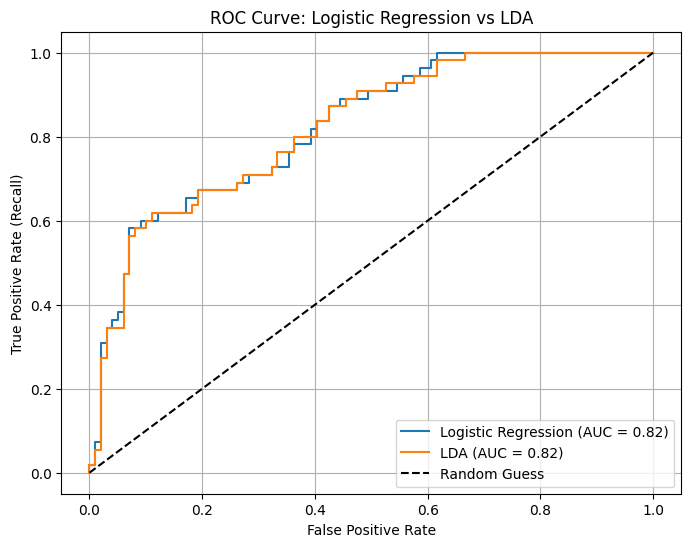

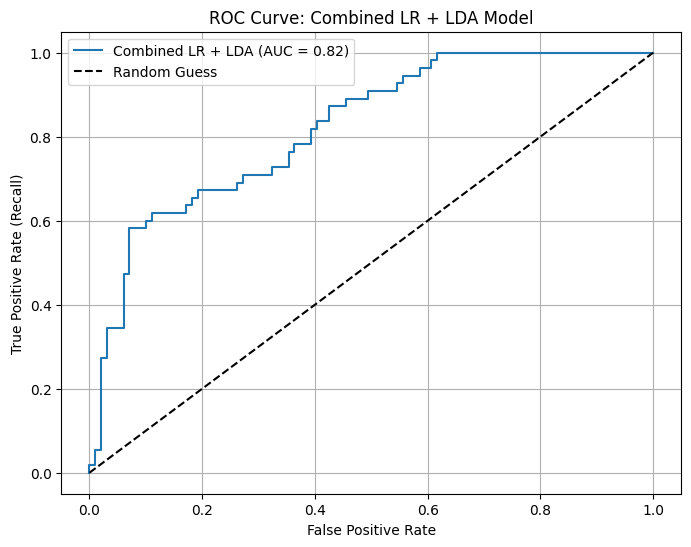

In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc


data = pd.read_csv("diabetes.csv")

#Data cleaning
invalid_zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

data[invalid_zero_columns] = data[invalid_zero_columns].replace(0, np.nan)

data.fillna(data.median(), inplace=True)

#Target Split
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

#Train-test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#MODEL COMPARISON PHASE

#Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

#Train LDA
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_scaled, y_train)

lda_pred = lda_model.predict(X_test_scaled)


#Evaluate both models (comparison)
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{model_name} Performance")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))


evaluate_model(y_test, lr_pred, "Logistic Regression")
evaluate_model(y_test, lda_pred, "LDA")


#Combine LR + LDA (OR logic)
combined_pred = np.where(
    (lr_pred == 1) | (lda_pred == 1),
    1,
    0
)

#combined model
evaluate_model(y_test, combined_pred, "Combined LR + LDA Model")

# Logistic Regression probabilities
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# LDA probabilities
lda_probs = lda_model.predict_proba(X_test_scaled)[:, 1]

# ROC for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
auc_lr = auc(fpr_lr, tpr_lr)

# ROC for LDA
fpr_lda, tpr_lda, _ = roc_curve(y_test, lda_probs)
auc_lda = auc(fpr_lda, tpr_lda)

#PLOT GRAPH 1 (COMPARISON)
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_lda, tpr_lda, label=f"LDA (AUC = {auc_lda:.2f})")
plt.plot([0,1], [0,1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve: Logistic Regression vs LDA")
plt.legend()
plt.grid(True)
plt.show()


#Create combined probabilities

combined_probs = np.maximum(lr_probs, lda_probs)

#ROC for combined model
fpr_comb, tpr_comb, _ = roc_curve(y_test, combined_probs)
auc_comb = auc(fpr_comb, tpr_comb)



#PLOT GRAPH 2 (FINAL MODEL)
plt.figure(figsize=(8,6))

plt.plot(fpr_comb, tpr_comb, label=f"Combined LR + LDA (AUC = {auc_comb:.2f})")
plt.plot([0,1], [0,1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve: Combined LR + LDA Model")
plt.legend()
plt.grid(True)
plt.show()
